In [51]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# POCS vs. Dykstra vs. ADMM

In [86]:
# Projection onto a hyperplane

def Proj_onto_hyperplane(point, a, b):
    x = cp.Variable(3)
    objective = cp.Minimize(cp.norm(x - point, 2))
    constraints = [a @ x == b]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return x.value

In [100]:
# Non-orthogonal hyperplanes

a1 = np.array([1, 1, 1])
b1 = 7
a2 = np.array([2, 10, -18])
b2 = -3



In [94]:
# Orthogonal hyperplanes
point = np.array([3, 7, 9])
 
a1 = np.array([1, 0, 0])
b1 = 7
a2 = np.array([0, 2, 0])
b2 = 5

In [101]:
# POCS

z = np.array([3, 7, 9])

for _ in range(5):
    z = Proj_onto_hyperplane(z, a1, b1)
    z = Proj_onto_hyperplane(z, a2, b2)
    print(z)

[-0.72429907  4.37850467  2.51869159]
[-0.4408682   4.69285527  2.72482313]
[-0.43292154  4.70166884  2.73060252]
[-0.43269873  4.70191595  2.73076456]
[-0.43269249  4.70192288  2.7307691 ]


In [105]:
# Dykstra


v = np.array([0, 0, 0])
u = np.array([0, 0, 0])

z = np.array([3, 7, 9])

for _ in range(5):
    x = Proj_onto_hyperplane(z + v, a1, b1)
    v = z + v - x
    z = Proj_onto_hyperplane(x + u, a2, b2)
    u = x + u - z
    print(x, z)


[-1.  3.  5.] [-0.72429907  4.37850467  2.51869159]
[-0.44859813  4.65420561  2.79439252] [-0.4408682   4.69285527  2.72482313]
[-0.43313827  4.7005852   2.73255306] [-0.43292154  4.70166884  2.73060252]
[-0.43270481  4.70188557  2.73081924] [-0.43269873  4.70191595  2.73076456]
[-0.43269266  4.70192203  2.73077063] [-0.43269249  4.70192288  2.7307691 ]


In [107]:
# ADMM for Projection 

u = np.array([0, 0, 0])
z = np.array([3, 7, 9])
rho = 20

for _ in range(5):
    x = Proj_onto_hyperplane((point + rho *(z - u))/(1+rho), a1, b1)
    z = Proj_onto_hyperplane(x + u, a2, b2)
    u = u + x - z
    print(x, z)



[-1.  3.  5.] [-0.72429907  4.37850467  2.51869159]
[0.05028927 6.15086782 0.7988429 ] [-0.18443075  4.97726772  2.91132309]
[-0.36875137  4.89374588  2.47500549] [-0.39982547  4.73837539  2.75467238]
[-0.43912947  4.68261159  2.75651788] [-0.43600113  4.69825329  2.72836282]
[-0.43504998  4.69485006  2.74019992] [-0.4339042   4.70057898  2.72988786]


# POISSON EQUATION

In [140]:
# Poisson Equation (Set-up)

delta_x = 0.01
np.random.seed(2)
f = np.random.rand(99) * 360
c = 10
rho = 200

A = np.diag(np.ones(99), 0) + np.diag(np.ones(98)*-1,  -1)

A_lastrow = np.zeros(99)
A_lastrow[-1] = -1
A = np.vstack([A, A_lastrow]) 
print(A)
print(A.shape)

# Remainder of the Poisson Equation
def F(u):
    return cp.sum_squares(u[1:] - u[:-1]) / delta_x + (u[0] ** 2)/ delta_x + (u[-1] ** 2) /delta_x - (f @ u) * delta_x


[[ 1.  0.  0. ...  0.  0.  0.]
 [-1.  1.  0. ...  0.  0.  0.]
 [ 0. -1.  1. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -1.  1.  0.]
 [ 0.  0.  0. ...  0. -1.  1.]
 [ 0.  0.  0. ...  0.  0. -1.]]
(100, 99)


In [141]:
# Finding u_{k+1}

def Argmin_u_update(z, w):
    u = cp.Variable (99)
    objective = cp.Minimize(F(u) + rho / 2 * cp.sum_squares(A@u - z + w)) 
    prob = cp.Problem(objective)
    prob.solve()
    return u.value


In [142]:
# Finding z_{k+1}

def Proj_onto_box(point):
    z = cp.Variable(100)
    objective = cp.Minimize(cp.norm(z - point, 2))
    constraints = [z >= -c * delta_x, z <= c * delta_x]
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return z.value

In [143]:
# ADMM for Poisson Equation

w = np.zeros(100)
z = np.zeros(100)
r_norm = []
s_norm = []

r_tol = 10e-5
s_tol = 10e-5

r_new = 10e5
s_new = 10e5

num_iter = 0

while r_tol < r_new or s_tol < s_new:
    u = Argmin_u_update(z, w) # x^{k+1}
    z_old = z.copy()
    z = Proj_onto_box(A@u + w) # z^{k+1}
    r = A@u - z # primal residual
    r_new = np.linalg.norm(r)
    r_norm.append(r_new)
    s = rho * A.T @ (z - z_old) # dual redisual
    s_new = np.linalg.norm(s)
    s_norm.append(s_new)
    w = w + A@u - z # w^{k+1}
    num_iter += 1


r_norm = np.array(r_norm)
s_norm = np.array(s_norm)
print(f"{num_iter} iterations needed for convergence")

   

35 iterations needed for convergence


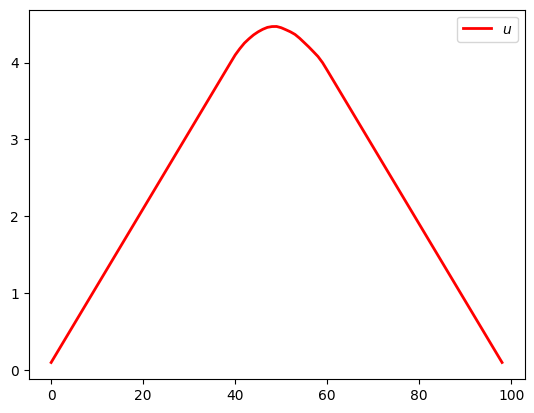

In [144]:
plt.close('all')
fig, ax = plt.subplots()
ax.plot(u, linewidth = 2, color = 'red', label = r'$u$')
ax.legend()


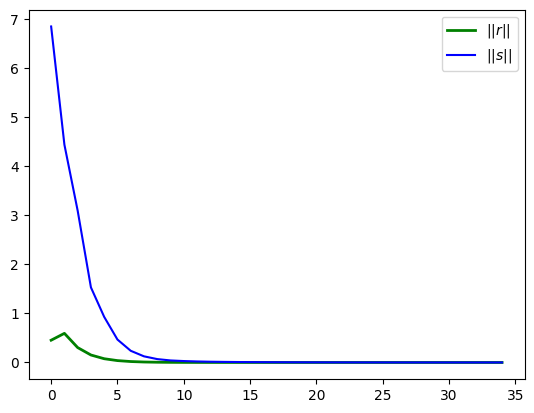

In [133]:
# Plotting the primal and dual residuals

plt.close('all')
fig, ax = plt.subplots()
ax.plot(r_norm, linewidth = 2, color = 'green', label = r'$||r||$')
ax.plot(s_norm, linewidth = 1.5, color = 'blue', label = r'$||s||$')
ax.legend()

